In [ ]:
# To link Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def clean():
    import gc
    import torch
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

import os
import torch
import models #type: ignore
import blosc2
import shutil
import importlib
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import torch.nn as nn
from copy import deepcopy
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from IPython.display import clear_output
from scipy.stats import mode,zscore,ttest_1samp
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

In [ ]:
def min_max_scale(X, min_max_range=(0,1)):
    min = min_max_range[0]
    max = min_max_range[1]
    if not isinstance(X, np.ndarray):
        X = X.numpy()
    X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
    X_scaled = X_std * (max - min) + min
    return X_scaled # outputs a numpy array

def chunk_and_reshape(spikes, lfp, seqlength, test_size=0.2, prediction_lag = 0, random_state=42):
    if len(lfp.shape) == 1:
        lfp = lfp[:, np.newaxis]
    if prediction_lag > 0:
        lfp_shifted = np.roll(lfp, -prediction_lag, axis=0)
        lfp_shifted = lfp_shifted[:-prediction_lag, :]
        spikes = spikes[:-prediction_lag, :]
    else:
        lfp_shifted = lfp
    num_trials = int(lfp_shifted.shape[0] / seqlength)
    if spikes.shape[0] % seqlength != 0:
        spikes = spikes[:-(spikes.shape[0] % seqlength), :]
        lfp_shifted = lfp_shifted[:-(lfp_shifted.shape[0] % seqlength), :]
    X_reshaped = torch.reshape(spikes, (num_trials, seqlength, spikes.shape[1]))
    lfp_reshaped = torch.reshape(lfp_shifted, (num_trials, seqlength, lfp_shifted.shape[1]))
    X_train, X_test, y_train, y_test = train_test_split(
        X_reshaped, lfp_reshaped, test_size=test_size, random_state=random_state
    )
    return X_train, X_test, y_train, y_test

def get_data_loaders(X_train, X_test, y_train, y_test, batch_size, device):
    X_train.to(device)
    X_test.to(device)
    y_train.to(device)
    y_test.to(device)
    train_dataset = TensorDataset(X_train, y_train)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_dataset = TensorDataset(X_test, y_test)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_dataloader, test_dataloader

In [ ]:
spikes_src = "/content/drive/MyDrive/spike_1119946360_raw.b2"
spikes_dst = "/content/spikes.b2"
shutil.copy(spikes_src, spikes_dst)
spikes = blosc2.load_tensor(spikes_dst)
fr_instant = spikes.numpy().copy() # get firing rate before scaling
spikes  = min_max_scale(spikes)

lfp_src = "/content/drive/MyDrive/lfp_1119946360.b2"
lfp_dst = "/content/lfp.b2"
shutil.copy(lfp_src, lfp_dst)
lfp = blosc2.load_tensor(lfp_dst)

sp = pd.read_csv("/content/drive/MyDrive/sp_1119946360.csv") # stimulus presentation df
df = pd.read_csv("/content/drive/MyDrive/units_info.csv",index_col=0)
units = pd.read_csv('/content/drive/MyDrive/units_1119946360.csv')
channels = pd.read_csv("/content/drive/MyDrive/channels_1119946360.csv")
timestamps = np.load("/content/drive/MyDrive/timestamps_1119946360.npy")

In [ ]:
seqlength = 750
chani = 5
bandi = 0
batch_size = 32
device = 'cuda'
input_size = spikes.shape[-1]
hidden_size = 50
num_layers = 1
num_epochs = 15
criterion = nn.MSELoss()

In [ ]:
# Calculate the spike triggered average LFP
# In this case we are using error times, not spike times
def spike_triggered_average(arr, spike_indices, window_pre, window_post):
    # arr: LFP
    # spike_indices: indices of spikes (or error) in arr
    # window_pre: number of samples before the spike
    # window_post: number of samples after the spike
    if not isinstance(arr, np.ndarray): arr = arr.numpy()
    if not isinstance(spike_indices, np.ndarray): spike_indices = spike_indices.numpy()
    # make sure we get full windows around each spike
    spike_indices = spike_indices[(spike_indices >= window_pre) & (spike_indices < len(arr) - window_post)]
    if len(spike_indices) == 0: return []
    num_spikes = len(spike_indices)
    time_offsets = np.arange(-window_pre, window_post + 1) # create a standard mask for the window
    # Form a window for each spike, shape of (num_spikes, window_pre + 1 + window_post)
    indices_matrix = spike_indices[:, np.newaxis] + time_offsets 
    all_segments = arr[indices_matrix]
    sta = np.mean(all_segments, axis=0)
    sta_std = np.std(all_segments, axis=0)
    sta_sem = sta_std / np.sqrt(num_spikes)
    return sta, sta_std, sta_sem

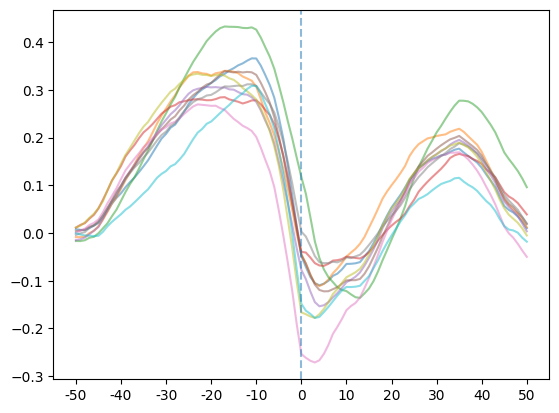

In [ ]:
#@title Test on the entire dataset
# Prevent non-continuous chunks from leaking through the edges
if isinstance(spikes, np.ndarray): spikes = torch.tensor(spikes).float()
X_train, X_test, y_train, y_test = chunk_and_reshape(spikes, lfp[:,chani,bandi], seqlength)
train_dataloader, test_dataloader = get_data_loaders(X_train,X_test,y_train,y_test,batch_size,device)
if (spikes.shape[0] % seqlength != 0):
    print("Not divisible by seqlength, ")
    spikes = spikes[:-(spikes.shape[0] % seqlength), :]
    lfp = lfp[:-(lfp.shape[0] % seqlength), :]
X_test_all = spikes.reshape(int(spikes.shape[0]/seqlength), seqlength, spikes.shape[1])
y_test_all = lfp[:,chani,bandi]

# train 10 models and compare results
for i in range(10): 
    model = models.process_model(models.LSTMnet(input_size=input_size,
                                                num_hidden=hidden_size,
                                                num_layers=num_layers,
                                                seqlength=seqlength
                                                ),criterion, device)
    train_loss, test_loss = model.train(train_dataloader, test_dataloader , num_epochs)
    yHat = model.evaluate(X_test_all)
    r2 = r2_score(yHat.cpu(), y_test_all)
    # obtain and zscore the prediction errors, and only focus on the ones bigger than 3 SD 
    error = zscore(yHat.cpu().numpy() - y_test_all.cpu().numpy())
    error_1sd = np.where(np.abs(error) > 3)[0] 

    sta, std, sem = spike_triggered_average(y_test_all, error_1sd, 50, 50)
    plt.plot(sta,alpha=0.5)
    plt.xticks(np.arange(0,101,10), np.arange(-50,51,10))
    # plt.fill_between(np.arange(0,101), sta-sem, sta+sem, alpha=0.2)
plt.axvline(50, alpha=0.5, linestyle='--')
plt.xlabel("Bins")
plt.ylabel("LFP (z-scored)")
plt.title(f"Error associated average LFP")

In [ ]:
#@title Check what are the errors associated with
# first get one model and find the errors
X_train, X_test,y_train, y_test = chunk_and_reshape(spikes, lfp[:,chani,bandi], seqlength)
train_dataloader, test_dataloader = get_data_loaders(X_train,X_test,y_train,y_test,batch_size,device)
X_test_all = spikes.reshape(int(spikes.shape[0]/seqlength), seqlength, spikes.shape[1])
y_test_all = lfp[:,chani,bandi]
model = models.process_model(models.LSTMnet(input_size=input_size,
                                            num_hidden=hidden_size,
                                            num_layers=num_layers,
                                            seqlength=seqlength
                                            ),criterion, device)
train_loss, test_loss = model.train(train_dataloader, test_dataloader , num_epochs)
yHat = model.evaluate(X_test_all)
r2 = r2_score(yHat.cpu(), y_test_all)
error = zscore(yHat.cpu().numpy() - y_test_all.cpu().numpy())
# very bad variable names, sorry
error_1sd = np.where(np.abs(error) > 2)[0] # 2SD to get more samples
error_1sd_bool = np.abs(error) > 2 # boolean mask
error_times = timestamps[error_1sd]

In [ ]:
# See if the errors are associated with stimulus presentation
sp = sp[sp['stimulus_block']==0]
in_stim = np.zeros(len(error)) 
starts = sp.start_time.values
ends = sp.end_time.values
starts_idx = np.searchsorted(timestamps, starts) # find the indices of the starts in the timestamps
ends_idx = np.searchsorted(timestamps, ends)
for idx, i in enumerate(starts_idx):
    in_stim[i:ends_idx[idx]] = 1 # mark the stimmulus presentation as 1, gray periods are 0s
results = in_stim[error_1sd]
# total numbers of time bins for each category
print(np.unique(results, return_counts=True))

(array([0., 1.]), array([25824, 17196]))


In [ ]:
# since there are more gray periods, we need to normalize bin counts by the total length of time
total_stim_time = np.sum(ends-starts)
total_gray_time = ends[-1] - starts[0] - total_stim_time
print(f"Total gray time: {total_gray_time}, total stim time: {total_stim_time}")

Total gray time: 2400.471616796547, total stim time: 1200.436014341042


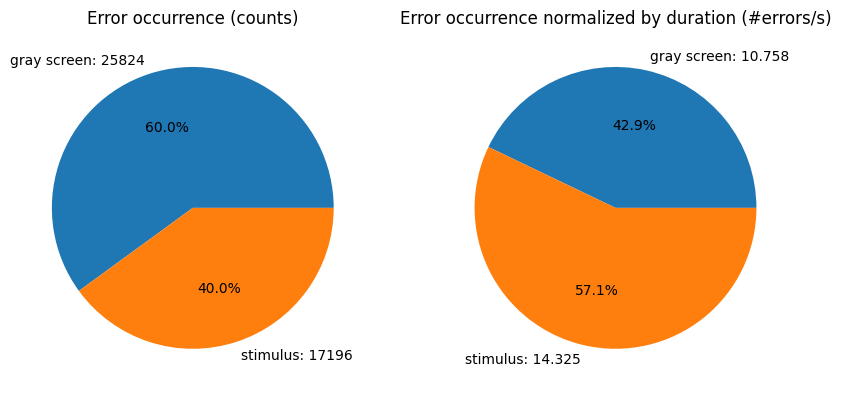

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,5))
counts = np.unique(results, return_counts=True)[1]
axs[0].pie(counts, labels=[f"gray screen: {counts[0]}", f"stimulus: {counts[1]}"], autopct='%1.1f%%')
axs[0].set_title("Error occurrence (counts)")
data = np.unique(results, return_counts=True)[1]/np.array([total_gray_time, total_stim_time])
axs[1].pie(data, labels=[f"gray screen: {data[0]:.3f}", f"stimulus: {data[1]:.3f}"], autopct='%1.1f%%')
axs[1].set_title("Error occurrence normalized by duration (#errors/s)");
# caveat: i did not take into account that mouse brains have reaction time, 
# so maybe an error occurs 4ms after the stimulus onset, for instance, should still be considered as in gray screens?
# not sure if this is applicable to LSTM

In [ ]:
# Check if errors are associated with specific images
image_all = sp.image_name.values
image_stats = sp.image_name.value_counts()
print(image_stats)
image_names = image_stats.index.values
image_counts = image_stats.values
image_dict = {}
for idx, image in enumerate(image_names):
    image_dict[image] = idx # giving each image a unique index

image_name
im034_r    676
im111_r    675
im024_r    609
im083_r    557
im114_r    553
im005_r    543
im087_r    541
im104_r    479
omitted    164
Name: count, dtype: int64


In [ ]:
image_arr = np.zeros(len(error))
image_arr.fill(np.nan) # fill with NaN to indicate gray screen periods
# reusing the start and end indices from above
for idx, i in enumerate(starts_idx):
    image_arr[i:ends_idx[idx]] = image_dict[image_all[idx]] # giving each time bin the image index
error_image_idx = image_arr[error_1sd_bool]
error_image_idx = error_image_idx[np.isnan(error_image_idx) == False] # remove NaNs

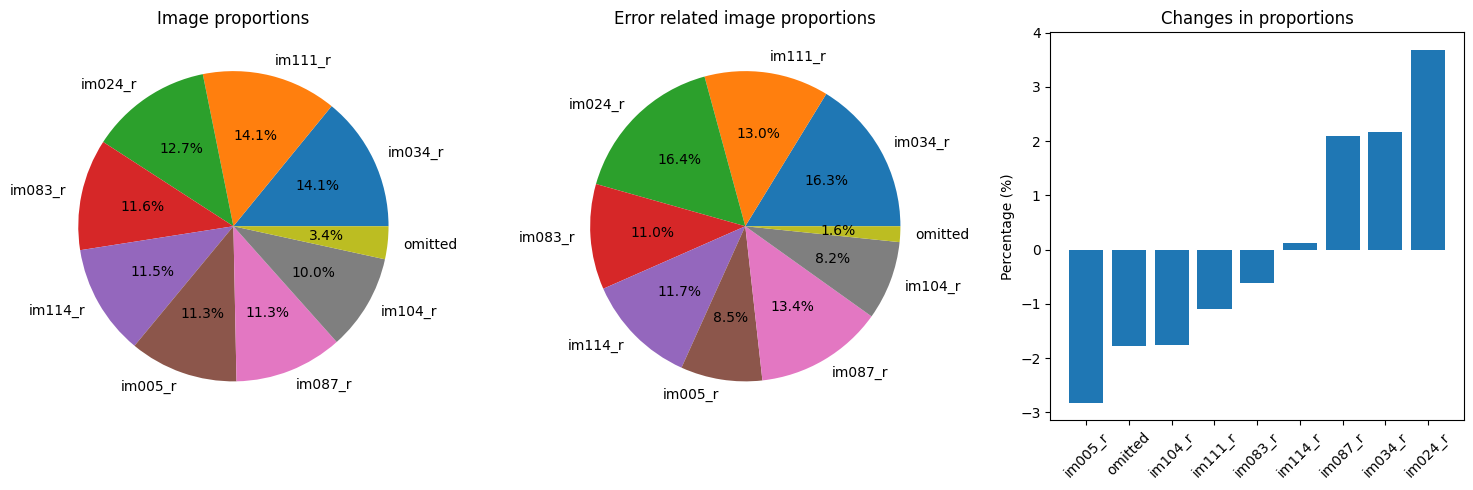

In [ ]:
# Convert image counts to proportions
fig, axs = plt.subplots(1,3, figsize=(15,5))
uniq, counts = np.unique(error_image_idx, return_counts=True)
labels = np.array(list(image_dict.keys()))[np.array(uniq,dtype=int)]

# Image proportions in the dataset
axs[0].set_title("Image proportions")
axs[0].pie(image_counts, labels=image_names, autopct='%1.1f%%');

# Image proportions of the errors
axs[1].set_title("Error related image proportions")
axs[1].pie(counts, labels=labels, autopct='%1.1f%%');

# Calculate the difference in proportions
error_counts_ratio = counts/np.sum(counts)
image_counts_ratio = image_counts/np.sum(image_counts)
diff = error_counts_ratio-image_counts_ratio
sequence = np.argsort(diff)
axs[2].set_title("Changes in proportions")
axs[2].bar(np.arange(len(labels)), (error_counts_ratio-image_counts_ratio)[sequence]*100)
axs[2].set_xticks(np.arange(len(labels)))
axs[2].set_xticklabels(np.array(list(image_dict.keys()))[sequence], rotation=45);
axs[2].set_ylabel("Percentage (%)")
plt.tight_layout()
plt.show()

# note: changes in proportions don't seem to correlate with the animals's task performance
# but this is just one trial

In [ ]:
# check if it's related to image change
# first find the errors associated with image changes
image_change = np.array(sp.is_change.values, dtype=bool)
# find the start and end indices of image changes
image_change_start_idx = starts_idx[image_change]
image_change_end_idx = ends_idx[image_change]
image_change_bool = np.zeros(len(error), dtype=bool) # set all to false
for i in range(len(image_change_start_idx)):
    image_change_bool[image_change_start_idx[i]:image_change_end_idx[i]] = True # mark image changes to True
image_change_results = image_change_bool[error_1sd_bool]
print(np.unique(image_change_results, return_counts=True))
image_changed = np.unique(image_change_results, return_counts=True)[1][1]
# 844 out of 43120 errors are associated with image changes

(array([False,  True]), array([42176,   844]))


In [ ]:
# then, find the errors associated with unchanged images
# get all unchanged images, excluding omitted images
image_unchange = ~(image_change) & ~(np.array(sp.omitted.values, dtype=bool)) 
image_unchange_start_idx = starts_idx[image_unchange]
image_unchange_end_idx = ends_idx[image_unchange]
image_unchange_bool = np.zeros(len(error), dtype=bool)
for i in range(len(image_unchange_start_idx)):
    image_unchange_bool[image_unchange_start_idx[i]:image_unchange_end_idx[i]] = True
image_unchange_results = image_unchange_bool[error_1sd_bool]
print(np.unique(image_unchange_results, return_counts=True))
image_unchanged = np.unique(image_unchange_results, return_counts=True)[1][1]
# 16071 out of 43120 errors are associated with unchanged images

(array([False,  True]), array([26949, 16071]))


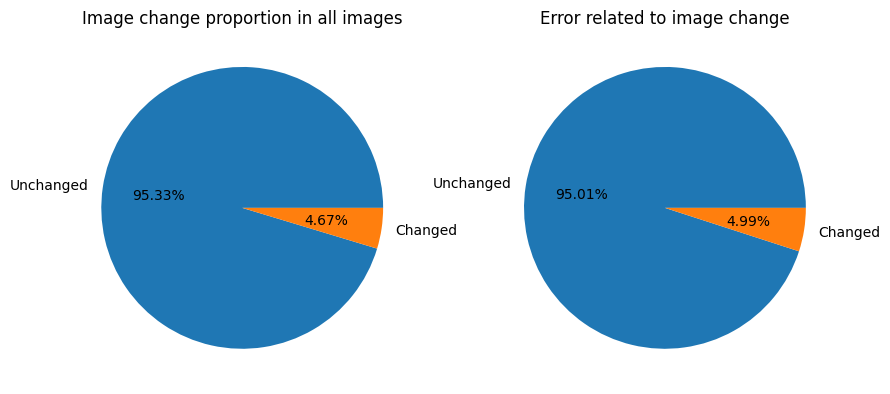

In [ ]:
# Plot the proportions of image changes vs unchanged images
# A small caveat here is that I also counted omitted images as unchanged, so the percentage should be slightly higher
fig,axs= plt.subplots(1,2, figsize=(10,5))
axs[0].set_title("Image change proportion in all images")
axs[0].pie(np.unique(image_change, return_counts=True)[1], labels=['Unchanged', 'Changed'], autopct='%1.2f%%')

axs[1].set_title("Error related to image change")
# #errors in change vs #errors in unchanged, automatically converted to percentages
axs[1].pie([image_unchanged, image_changed], labels=["Unchanged", 'Changed'], autopct='%1.2f%%');

In [ ]:
# find the probability density function of error in during an averaged stimulus presentation trial
error_1sd_int = np.array(error_1sd_bool, dtype=int)
# 125ms before, 250ms stim, 125ms after
window_pre = 31
window_post = 94
# get the averaged segments aligned to stimulus onset
time_offsets = np.arange(-window_pre, window_post)
indices_matrix = starts_idx[:, np.newaxis] + time_offsets
all_segments = error_1sd_int[indices_matrix]
probability_density = np.sum(all_segments, axis=0)/np.sum(all_segments)
lfp_aligned = lfp[:,chani,bandi][indices_matrix]

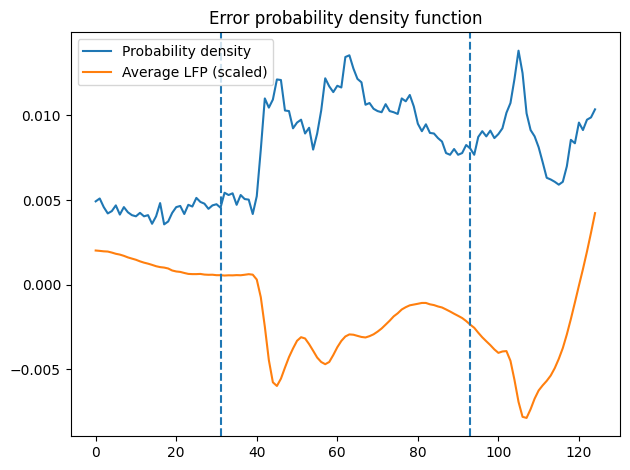

In [ ]:
plt.title("Error probability density function")
plt.plot(probability_density, label="Probability density")
plt.plot(lfp_aligned.mean(axis=0)/150, label="Average LFP (scaled)")
# plt.xticks(np.arange(0,126,25))
plt.axvline(31, linestyle='--')
plt.axvline(93, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show();